In [1]:
MODEL_CLS = "acf"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\09_RS-DACR


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import dacr

In [6]:
kwargs = dict(
    path=PATH_CONFIG_FILE,
)

cfg = config.builder.config_builder(**kwargs)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [9]:
kwargs = dict(
    df=df,
    schema=cfg.schema,
    percentaile=0.9,
)

utils.description.main(**kwargs)

number of user: 609
number of item: 8452
total interaction: 81763
interaction density: 1.5885 %
max interaction of user: 2117
max interaction of item: 315
top 10.0 % interaction of user: 344.4
top 10.0 % interaction of item: 25.0
mean interaction of user: 134
mean interaction of item: 9


In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.arl.num_users,
    num_items=cfg.model.arl.num_items,
    **cfg.model.arl.params,
)

arl = dacr.arl.Module(**kwargs)

In [12]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.aml.num_users,
    num_items=cfg.model.aml.num_items,
    **cfg.model.aml.params,
)

aml = dacr.aml.Module(**kwargs)

In [13]:
kwargs = dict(
    arl=arl,
    aml=aml,
)    

model = dacr.acf.Module(**kwargs)

# Train

In [14]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [15]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.5103
	BEST EPOCH: 23


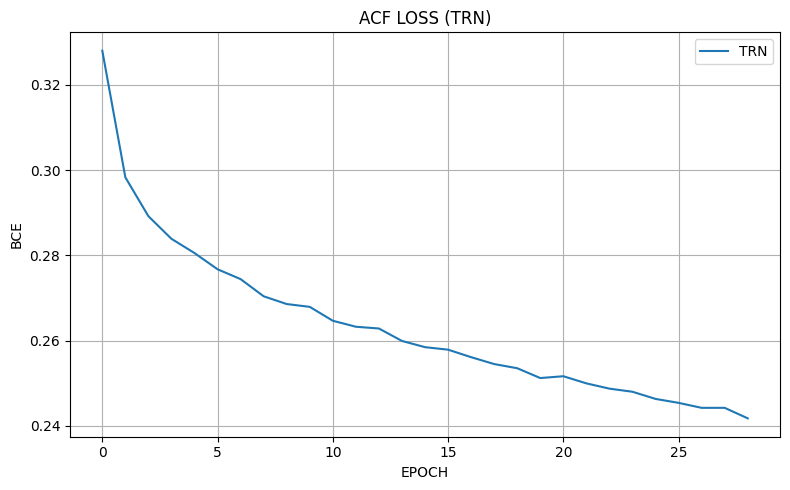

In [16]:
kwargs = dict(
    record=records["trn"],
    label="TRN",
    criterion="BCE",
    title="ACF LOSS (TRN)",
)

utils.visualizer.main(**kwargs)

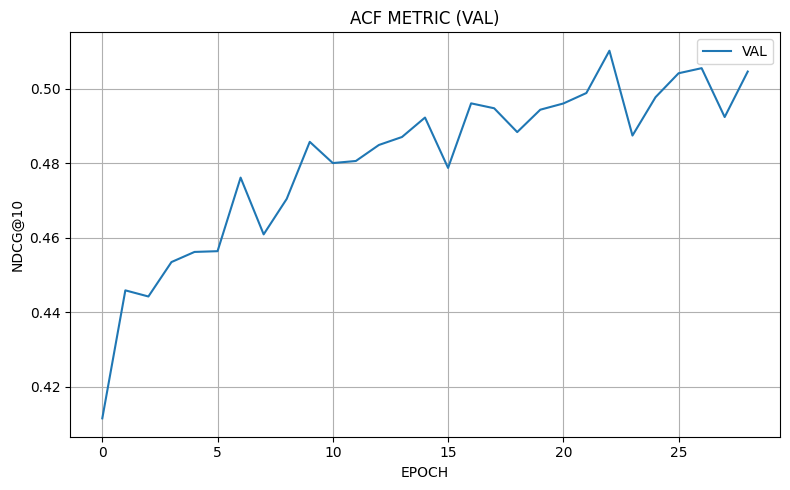

In [17]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="ACF METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [18]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [19]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3195/3195 [00:09<00:00, 335.92it/s]


In [20]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.876645,0.410855,0.345513,0.253932,0.501125
1,10,0.955592,0.310855,0.482160,0.308154,0.511795
2,15,0.976974,0.252303,0.553293,0.329651,0.522251
3,20,0.981908,0.216530,0.598552,0.341780,0.531649
4,25,0.990132,0.191908,0.636924,0.350071,0.541362
5,50,1.000000,0.124572,0.743950,0.368931,0.571355


# Save

In [21]:
PATH = f'./checkpoints/{cfg.dataset}/{cfg.model_cls}_{cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)